In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# hyprcoloc = pd.read_csv('../code/results/coloc/hyprcoloc_results_allTissues/tables/hyprcoloc_results.tsv.gz', sep='\t')
hyprcoloc = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/hyprcoloc_results.tsv.gz', sep='\t')


In [3]:
hyprcoloc.traits

0         Adipose-Subcutaneous.leafcutter_N_N_chr10:1009...
1         Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...
2                                                       NaN
3                                                       NaN
4         Adipose-Subcutaneous.leafcutter_N_N_chr10:1010...
                                ...                        
669143                                                  NaN
669144                                                  NaN
669145                                                  NaN
669146                                                  NaN
669147                                                  NaN
Name: traits, Length: 669148, dtype: object

In [4]:
gwas_colocs = []
up_colocs = []
expr_colocs = []
lfc_colocs = []
lfc_other_colocs = []
lfc_and_expression = []
pr_and_expression = []
up_and_expression = []
for idx, row in hyprcoloc.iterrows():
    if row.traits is np.nan:
        gwas_colocs.append(False)
        up_colocs.append(False)
        expr_colocs.append(False)
        lfc_colocs.append(False)
        lfc_other_colocs.append(False)
        lfc_and_expression.append(False)
        pr_and_expression.append(False)
        up_and_expression.append(False)
    else:
        trait_list = row.traits.split(', ')
        gwas_coloc = row.gwas_trait in trait_list
        if gwas_coloc:
            gwas_colocs.append(True)
        else:
            gwas_colocs.append(False)
        if ':UP' in row.traits:
            up_colocs.append(True)
        else:
            up_colocs.append(False)
            
        if (':NE' in row.traits) or (':IN' in row.traits):
            lfc_other_colocs.append(True)
        else:
            lfc_other_colocs.append(False)
        
        if 'expression' in row.traits:
            expr_colocs.append(True)
        else:
            expr_colocs.append(False)
        if 'leafcutter' in row.traits:
            lfc_colocs.append(True)
        else:
            lfc_colocs.append(False)
            
        pr_genes = sorted(set([x.split(':')[-1].split('.')[0] for x in trait_list if ':PR:' in x]))
        up_genes = sorted(set([x.split(':')[-1].split('.')[0] for x in trait_list if ':UP:' in x]))
        exp_genes = sorted(set([x.split('_')[-1] for x in trait_list if '.expression_N_N_' in x]))
        
        pr_exp = set(pr_genes).intersection(set(exp_genes))
        up_exp = set(up_genes).intersection(set(exp_genes))
        
        if (len(pr_exp)>0) or (len(up_exp) > 0):
            lfc_and_expression.append(True)
        else:
            lfc_and_expression.append(False)
        if (len(pr_exp)>0):
            pr_and_expression.append(True)
        else:
            pr_and_expression.append(False)
        if (len(up_exp)>0):
            up_and_expression.append(True)
        else:
            up_and_expression.append(False)
        

In [5]:
pr_genes

['ENSG00000106803']

In [6]:
hyprcoloc.traits.iloc[0]
pr_genes = sorted(set([x.split(':')[-1].split('.')[0] for x in hyprcoloc.traits.iloc[0].split(', ') if ':PR:' in x]))
up_genes = sorted(set([x.split(':')[-1].split('.')[0] for x in hyprcoloc.traits.iloc[0].split(', ') if ':UP:' in x]))
exp_genes = sorted(set([x.split('_')[-1] for x in hyprcoloc.traits.iloc[0].split(', ') if '.expression_N_N_' in x]))

In [104]:
set(pr_genes).intersection(set(exp_genes))

{'ENSG00000055950'}

In [99]:
exp_genes

['ENSG00000055950', 'ENSG00000107816']

In [7]:
hyprcoloc['gwas_colocs'] = gwas_colocs
hyprcoloc['UP_colocs'] = up_colocs
hyprcoloc['expr_colocs'] = expr_colocs
hyprcoloc['lfc_colocs'] = lfc_colocs
hyprcoloc['lfc_other_colocs'] = lfc_other_colocs

hyprcoloc['gwas_loci'] = hyprcoloc.gwas_trait
hyprcoloc['lfc_exp'] = lfc_and_expression
hyprcoloc['pr_exp'] = pr_and_expression
hyprcoloc['up_exp'] = up_and_expression


In [127]:
hyprcoloc

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,lfc_exp,pr_exp,up_exp
0,1,Adipose-Subcutaneous.leafcutter_N_N_chr10:1009...,0.5347,0.9546,chr10_100983006_C_A_b38,0.2561,NaN,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,True,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,True,True,False
1,2,Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...,0.6701,0.9998,chr10_100498682_C_T_b38,0.5757,NaN,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,True,False,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False
2,3,NaN,NaN,0.9926,NaN,NaN,Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False,False,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False
3,4,NaN,NaN,0.2464,NaN,NaN,Adipose-Subcutaneous.expression_N_N_ENSG000000...,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False,False,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False
4,5,Adipose-Subcutaneous.leafcutter_N_N_chr10:1010...,0.9924,1.0000,chr10_101044468_C_A_b38,0.3763,NaN,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,True,False,True,False,chr10_100705496_N_N_Visceral_adipose_tissue_me...,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669143,3,NaN,NaN,0.0065,NaN,NaN,Thyroid.expression_N_N_ENSG00000204291,chr9_99568999_N_N_Atopic_eczema,False,False,False,False,False,chr9_99568999_N_N_Atopic_eczema,False,False,False
669144,4,NaN,NaN,0.0016,NaN,NaN,Thyroid.expression_N_N_ENSG00000119508,chr9_99568999_N_N_Atopic_eczema,False,False,False,False,False,chr9_99568999_N_N_Atopic_eczema,False,False,False
669145,1,NaN,NaN,0.0308,NaN,NaN,WholeBlood.expression_N_N_ENSG00000136874,chr9_99568999_N_N_Atopic_eczema,False,False,False,False,False,chr9_99568999_N_N_Atopic_eczema,False,False,False
669146,2,NaN,NaN,0.0051,NaN,NaN,chr9_99568999_N_N_Atopic_eczema,chr9_99568999_N_N_Atopic_eczema,False,False,False,False,False,chr9_99568999_N_N_Atopic_eczema,False,False,False


In [110]:
trait_list

['Testis.leafcutter_N_N_chr9:99222171:99222545:clu_20454_+:PR:ENSG00000106803.9',
 'Testis.leafcutter_N_N_chr9:99222366:99222545:clu_20454_+:PR:ENSG00000106803.9',
 'Testis.expression_N_N_ENSG00000106803']

In [37]:
(hyprcoloc_colocs.trait_snp_pos - hyprcoloc_colocs.candidate_snp_pos).abs()

0        170222
1          7518
2             0
3             0
4        144029
          ...  
17060    149668
17061    149668
17062      8363
17063      8363
17064      4770
Length: 17065, dtype: int64

In [8]:
leadSNPs = pd.read_csv('../code/resources/gwas/LeadSnpWindows.bed', sep='\t', names = ['chrom', 'start', 'end', 'gwas_loci'])
leadSNPs['gwas_trait'] = leadSNPs.gwas_loci.apply(lambda x: x.split('_N_N_')[1])

In [121]:
hyprcoloc

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,lfc_exp,pr_exp,up_exp
0,1,Adipose-Subcutaneous.leafcutter_N_N_chr10:1009...,0.5347,0.9546,chr10_100983006_C_A_b38,0.2561,NaN,Visceral_adipose_tissue_measurement,False,False,True,True,False,Visceral_adipose_tissue_measurement,True,True,False
1,2,Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...,0.6701,0.9998,chr10_100498682_C_T_b38,0.5757,NaN,Visceral_adipose_tissue_measurement,False,True,False,True,False,Visceral_adipose_tissue_measurement,False,False,False
2,3,NaN,NaN,0.9926,NaN,NaN,Adipose-Subcutaneous.leafcutter_N_N_chr10:1004...,Visceral_adipose_tissue_measurement,False,False,False,False,False,Visceral_adipose_tissue_measurement,False,False,False
3,4,NaN,NaN,0.2464,NaN,NaN,Adipose-Subcutaneous.expression_N_N_ENSG000000...,Visceral_adipose_tissue_measurement,False,False,False,False,False,Visceral_adipose_tissue_measurement,False,False,False
4,5,Adipose-Subcutaneous.leafcutter_N_N_chr10:1010...,0.9924,1.0000,chr10_101044468_C_A_b38,0.3763,NaN,Visceral_adipose_tissue_measurement,False,True,False,True,False,Visceral_adipose_tissue_measurement,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669143,3,NaN,NaN,0.0065,NaN,NaN,Thyroid.expression_N_N_ENSG00000204291,Atopic_eczema,False,False,False,False,False,Atopic_eczema,False,False,False
669144,4,NaN,NaN,0.0016,NaN,NaN,Thyroid.expression_N_N_ENSG00000119508,Atopic_eczema,False,False,False,False,False,Atopic_eczema,False,False,False
669145,1,NaN,NaN,0.0308,NaN,NaN,WholeBlood.expression_N_N_ENSG00000136874,Atopic_eczema,False,False,False,False,False,Atopic_eczema,False,False,False
669146,2,NaN,NaN,0.0051,NaN,NaN,chr9_99568999_N_N_Atopic_eczema,Atopic_eczema,False,False,False,False,False,Atopic_eczema,False,False,False


In [15]:
hyprcoloc['gwas_trait'] = hyprcoloc.gwas_loci.apply(lambda x: x.split('_N_N_')[1])

In [16]:
hyprcoloc_colocs = hyprcoloc.loc[hyprcoloc.gwas_colocs].reset_index(drop=True).copy()
hyprcoloc_colocs['candidate_snp_pos'] = hyprcoloc_colocs.candidate_snp.apply(lambda x: int(x.split('_')[1]))
hyprcoloc_colocs['trait_snp_pos'] = hyprcoloc_colocs.gwas_loci.apply(lambda x: int(x.split('_')[1]))
hyprcoloc_colocs['distance'] = (hyprcoloc_colocs.candidate_snp_pos - hyprcoloc_colocs.trait_snp_pos).abs()

In [130]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.distance <= 1000]

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,lfc_exp,pr_exp,up_exp,candidate_snp_pos,trait_snp_pos,distance
2,1,"chr10_101845957_N_N_atrial_fibrillation, Brain...",0.8693,0.9193,chr10_101845957_T_C_b38,0.4125,NaN,atrial_fibrillation,True,False,False,True,False,chr10_101845957_N_N_atrial_fibrillation,False,False,False,101845957,101845957,0
3,3,"chr10_101845957_N_N_atrial_fibrillation, Esoph...",0.7549,0.7714,chr10_101845957_T_C_b38,0.6902,NaN,atrial_fibrillation,True,False,True,False,False,chr10_101845957_N_N_atrial_fibrillation,False,False,False,101845957,101845957,0
6,3,"chr10_101845957_N_N_atrial_fibrillation, Muscl...",0.4943,0.5272,chr10_101845957_T_C_b38,0.2994,NaN,atrial_fibrillation,True,False,True,False,False,chr10_101845957_N_N_atrial_fibrillation,False,False,False,101845957,101845957,0
7,2,"chr10_101845957_N_N_atrial_fibrillation, Skin-...",0.5026,0.5526,chr10_101845957_T_C_b38,0.5880,NaN,atrial_fibrillation,True,False,True,False,False,chr10_101845957_N_N_atrial_fibrillation,False,False,False,101845957,101845957,0
8,4,"chr10_101845957_N_N_atrial_fibrillation, Skin-...",0.8481,0.8831,chr10_101845957_T_C_b38,0.5905,NaN,atrial_fibrillation,True,False,False,True,False,chr10_101845957_N_N_atrial_fibrillation,False,False,False,101845957,101845957,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17043,1,"chr9_681645_N_N_basal_cell_carcinoma, Muscle-S...",0.9886,0.9999,chr9_681862_C_A_b38,0.4783,NaN,basal_cell_carcinoma,True,False,True,False,False,chr9_681645_N_N_basal_cell_carcinoma,False,False,False,681862,681645,217
17046,2,chr9_89594236_N_N_Visceral_adipose_tissue_meas...,0.6130,0.6458,chr9_89594236_G_C_b38,0.3027,NaN,Visceral_adipose_tissue_measurement,True,False,True,False,False,chr9_89594236_N_N_Visceral_adipose_tissue_meas...,False,False,False,89594236,89594236,0
17049,4,chr9_92391447_N_N_Chronic_obstructive_pulmonar...,0.4513,0.6262,chr9_92391447_C_G_b38,0.0549,NaN,Chronic_obstructive_pulmonary_disease,True,False,True,False,False,chr9_92391447_N_N_Chronic_obstructive_pulmonar...,False,False,False,92391447,92391447,0
17053,3,chr9_92391447_N_N_Chronic_obstructive_pulmonar...,0.4689,0.8704,chr9_92391447_C_G_b38,0.0587,NaN,Chronic_obstructive_pulmonary_disease,True,False,True,False,False,chr9_92391447_N_N_Chronic_obstructive_pulmonar...,False,False,False,92391447,92391447,0


In [131]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.distance <= 1].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    139
Visceral_adipose_tissue_measurement       85
schizophrenia                             70
Hypothyroidism                            65
GCST004131                                56
coronary_artery_disease                   55
GCST004132                                49
GCST004988                                43
myocardial_infarction                     42
GCST007800                                36
basal_cell_carcinoma                      35
GCST004133                                33
Atopic_eczema                             27
age_when_finished_full-time_education     26
bipolar_disorder                          24
atrial_fibrillation                       23
Dupuytrens_disease                        21
IMSGC2019                                 20
heart_failure                              7
Name: count, dtype: int64

In [55]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.distance <= 0].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()

gwas_trait
Atopic_eczema                            0.385714
Chronic_obstructive_pulmonary_disease    0.319444
Dupuytrens_disease                       0.328125
GCST004131                               0.397163
GCST004132                               0.505155
GCST004133                               0.532258
GCST004988                               0.255952
GCST007800                               0.330275
Hypothyroidism                           0.430464
IMSGC2019                                0.263158
Rheumatoid_arthritis                          NaN
Visceral_adipose_tissue_measurement      0.261538
age_when_finished_full-time_education    0.084691
atrial_fibrillation                      0.207207
basal_cell_carcinoma                     0.372340
bipolar_disorder                         0.369231
coronary_artery_disease                  0.248869
heart_failure                            0.166667
myocardial_infarction                    0.500000
schizophrenia                          

In [17]:
hyprcoloc.loc[(hyprcoloc.gwas_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    253
Visceral_adipose_tissue_measurement      188
coronary_artery_disease                  156
age_when_finished_full-time_education    136
schizophrenia                            105
Hypothyroidism                           101
GCST004131                                88
GCST004988                                82
atrial_fibrillation                       74
GCST004132                                71
GCST007800                                66
myocardial_infarction                     61
basal_cell_carcinoma                      56
IMSGC2019                                 56
GCST004133                                43
Atopic_eczema                             43
bipolar_disorder                          42
Dupuytrens_disease                        33
heart_failure                             22
Rheumatoid_arthritis                      15
Name: count, dtype: int64

In [17]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.gwas_colocs) & (hyprcoloc_colocs.UP_colocs) & (hyprcoloc_colocs.distance <= 1000000)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    33
Visceral_adipose_tissue_measurement      30
age_when_finished_full-time_education    27
coronary_artery_disease                  22
schizophrenia                            17
GCST004988                               12
Hypothyroidism                           12
GCST004131                               12
bipolar_disorder                         11
IMSGC2019                                11
GCST007800                                9
myocardial_infarction                     8
basal_cell_carcinoma                      7
GCST004132                                6
heart_failure                             5
GCST004133                                5
Dupuytrens_disease                        4
atrial_fibrillation                       4
Atopic_eczema                             1
Name: count, dtype: int64

In [79]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.gwas_colocs) & (hyprcoloc_colocs.UP_colocs) & (hyprcoloc_colocs.expr_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
age_when_finished_full-time_education    20
Visceral_adipose_tissue_measurement      16
Chronic_obstructive_pulmonary_disease    15
coronary_artery_disease                  14
schizophrenia                            11
GCST004988                                8
bipolar_disorder                          7
IMSGC2019                                 7
GCST007800                                6
Hypothyroidism                            6
myocardial_infarction                     5
GCST004131                                4
GCST004133                                3
atrial_fibrillation                       2
GCST004132                                2
Dupuytrens_disease                        1
basal_cell_carcinoma                      1
heart_failure                             1
Name: count, dtype: int64

In [86]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.gwas_colocs) & (hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.expr_colocs) ].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Visceral_adipose_tissue_measurement      60
age_when_finished_full-time_education    56
Chronic_obstructive_pulmonary_disease    52
coronary_artery_disease                  51
schizophrenia                            28
IMSGC2019                                25
GCST004131                               22
GCST007800                               20
GCST004988                               19
Hypothyroidism                           16
atrial_fibrillation                      16
GCST004132                               16
bipolar_disorder                         14
myocardial_infarction                    14
basal_cell_carcinoma                     13
Atopic_eczema                             9
heart_failure                             8
GCST004133                                8
Dupuytrens_disease                        4
Name: count, dtype: int64

In [82]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.gwas_colocs) & (hyprcoloc_colocs.expr_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    233
Visceral_adipose_tissue_measurement      179
coronary_artery_disease                  150
age_when_finished_full-time_education    121
schizophrenia                             99
Hypothyroidism                            94
GCST004131                                86
GCST004988                                75
GCST004132                                70
atrial_fibrillation                       70
GCST007800                                62
myocardial_infarction                     60
basal_cell_carcinoma                      54
IMSGC2019                                 53
GCST004133                                41
bipolar_disorder                          41
Atopic_eczema                             39
Dupuytrens_disease                        29
heart_failure                             21
Rheumatoid_arthritis                      12
Name: count, dtype: int64

In [78]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.gwas_colocs) & (hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.distance <= 1000000)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    123
Visceral_adipose_tissue_measurement      115
age_when_finished_full-time_education     83
coronary_artery_disease                   83
schizophrenia                             52
Hypothyroidism                            39
GCST004131                                37
GCST004988                                35
IMSGC2019                                 35
atrial_fibrillation                       34
GCST007800                                32
GCST004132                                31
basal_cell_carcinoma                      28
myocardial_infarction                     25
bipolar_disorder                          23
Atopic_eczema                             20
GCST004133                                15
Dupuytrens_disease                        15
heart_failure                             13
Rheumatoid_arthritis                       4
Name: count, dtype: int64

In [18]:
barplot_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.UP_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df.columns = ['u-sQTLs']

other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & ((hyprcoloc.UP_colocs) |(hyprcoloc.lfc_other_colocs))].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls']


other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.lfc_colocs) & (~(((hyprcoloc.UP_colocs) |(hyprcoloc.lfc_other_colocs)))) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs']

other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.expr_colocs) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs', 'eQTLs']

other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.expr_colocs) & (~(hyprcoloc.lfc_colocs)) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs', 'eQTLs', 'eQTLs_only']


other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.lfc_colocs) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs', 'eQTLs', 'eQTLs_only', 'sQTLs']

other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.lfc_colocs) & (~(hyprcoloc.expr_colocs)) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs', 'eQTLs', 'eQTLs_only', 'sQTLs', 'sQTLs_only']



other_df = pd.DataFrame((hyprcoloc.loc[(hyprcoloc.gwas_colocs) ].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))

barplot_df = pd.merge(barplot_df, other_df, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'other_sqtls', 'p-sQTLs', 'eQTLs', 'eQTLs_only', 'sQTLs', 'sQTLs_only', 'coloc_any']



In [19]:
cols = sns.color_palette("Set3")

In [20]:
barplot_df.head()

,u-sQTLs,other_sqtls,p-sQTLs,eQTLs,eQTLs_only,sQTLs,sQTLs_only,coloc_any
gwas_trait,,,,,,,,
Atopic_eczema,0.014286,0.028571,0.271429,0.557143,0.557143,0.285714,0.271429,0.614286
Chronic_obstructive_pulmonary_disease,0.076389,0.129630,0.229167,0.539352,0.532407,0.284722,0.252315,0.585648
Dupuytrens_disease,0.062500,0.093750,0.156250,0.453125,0.453125,0.234375,0.218750,0.515625
GCST004131,0.085106,0.113475,0.191489,0.609929,0.602837,0.262411,0.212766,0.624113
GCST004132,0.061856,0.113402,0.278351,0.721649,0.690722,0.319588,0.288660,0.731959


Text(0, 0.5, 'Percentahe colocalized loci')

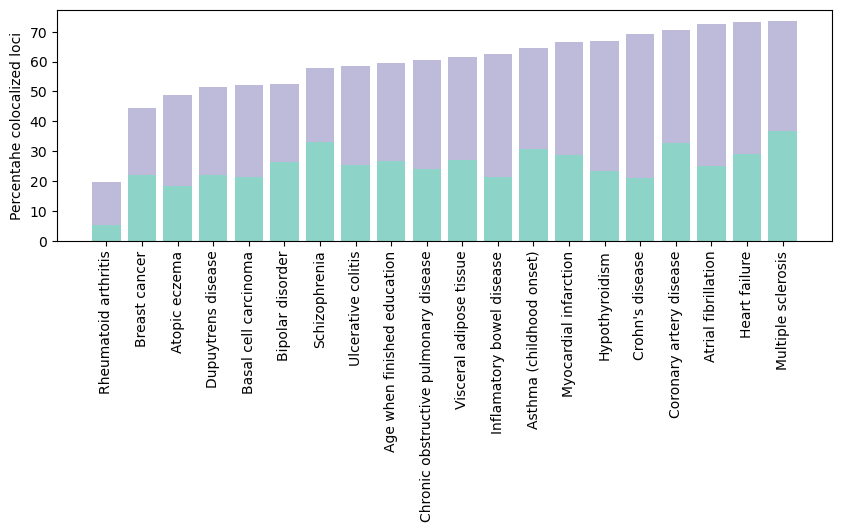

In [21]:
fig, ax = plt.subplots(figsize=(10, 3))
pos = 0
for trait, row in barplot_df.sort_values('coloc_any').iterrows():
    ax.bar([pos], [100*row.coloc_any ], color=cols[2])
    ax.bar([pos], [100*(row.sQTLs_only + row.coloc_any - (row.sQTLs_only + row.eQTLs_only))], color=cols[1])
    ax.bar([pos], [100*row.sQTLs_only], color=cols[0])
    
    pos += 1
    
xlabels = ['Rheumatoid arthritis', 'Breast cancer', 'Atopic eczema', 'Dupuytrens disease', 'Basal cell carcinoma', 
          'Bipolar disorder', 'Schizophrenia', 'Ulcerative colitis', 'Age when finished education', 
           'Chronic obstructive pulmonary disease', 'Visceral adipose tissue', 'Inflamatory bowel disease',
          'Asthma (childhood onset)', 'Myocardial infarction', 'Hypothyroidism', "Crohn's disease", 'Coronary artery disease',
          'Atrial fibrillation', 'Heart failure', 'Multiple sclerosis']
    
ax.set_xticks(range(20), xlabels, rotation=90)
ax.set_ylabel('Percentahe colocalized loci')

In [141]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.UP_colocs].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    33
Visceral_adipose_tissue_measurement      30
age_when_finished_full-time_education    27
coronary_artery_disease                  22
schizophrenia                            17
GCST004988                               12
Hypothyroidism                           12
GCST004131                               12
bipolar_disorder                         11
IMSGC2019                                11
GCST007800                                9
myocardial_infarction                     8
basal_cell_carcinoma                      7
GCST004132                                6
heart_failure                             5
GCST004133                                5
Dupuytrens_disease                        4
atrial_fibrillation                       4
Atopic_eczema                             1
Name: count, dtype: int64

In [149]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.lfc_colocs].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    123
Visceral_adipose_tissue_measurement      115
age_when_finished_full-time_education     83
coronary_artery_disease                   83
schizophrenia                             52
Hypothyroidism                            39
GCST004131                                37
GCST004988                                35
IMSGC2019                                 35
atrial_fibrillation                       34
GCST007800                                32
GCST004132                                31
basal_cell_carcinoma                      28
myocardial_infarction                     25
bipolar_disorder                          23
Atopic_eczema                             20
GCST004133                                15
Dupuytrens_disease                        15
heart_failure                             13
Rheumatoid_arthritis                       4
Name: count, dtype: int64

In [150]:
hyprcoloc_colocs.loc[hyprcoloc_colocs.gwas_colocs].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    253
Visceral_adipose_tissue_measurement      188
coronary_artery_disease                  156
age_when_finished_full-time_education    136
schizophrenia                            105
Hypothyroidism                           101
GCST004131                                88
GCST004988                                82
atrial_fibrillation                       74
GCST004132                                71
GCST007800                                66
myocardial_infarction                     61
basal_cell_carcinoma                      56
IMSGC2019                                 56
GCST004133                                43
Atopic_eczema                             43
bipolar_disorder                          42
Dupuytrens_disease                        33
heart_failure                             22
Rheumatoid_arthritis                      15
Name: count, dtype: int64

In [155]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.UP_colocs) & (hyprcoloc_colocs.distance <= 10000)].groupby('gwas_loci').gwas_trait.first().value_counts()/hyprcoloc_colocs.loc[hyprcoloc_colocs.gwas_colocs].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Atopic_eczema                            0.023256
Chronic_obstructive_pulmonary_disease    0.083004
Dupuytrens_disease                       0.060606
GCST004131                               0.079545
GCST004132                               0.056338
GCST004133                               0.069767
GCST004988                               0.073171
GCST007800                               0.106061
Hypothyroidism                           0.059406
IMSGC2019                                0.107143
Rheumatoid_arthritis                          NaN
Visceral_adipose_tissue_measurement      0.063830
age_when_finished_full-time_education    0.051471
atrial_fibrillation                      0.040541
basal_cell_carcinoma                     0.089286
bipolar_disorder                         0.071429
coronary_artery_disease                  0.096154
heart_failure                            0.136364
myocardial_infarction                    0.081967
schizophrenia                          

In [154]:
hyprcoloc_colocs.loc[(~hyprcoloc_colocs.UP_colocs) & (hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.distance <= 10000)].groupby('gwas_loci').gwas_trait.first().value_counts()/hyprcoloc_colocs.loc[hyprcoloc_colocs.gwas_colocs].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Atopic_eczema                            0.232558
Chronic_obstructive_pulmonary_disease    0.280632
Dupuytrens_disease                       0.151515
GCST004131                               0.204545
GCST004132                               0.253521
GCST004133                               0.209302
GCST004988                               0.256098
GCST007800                               0.333333
Hypothyroidism                           0.188119
IMSGC2019                                0.267857
Rheumatoid_arthritis                          NaN
Visceral_adipose_tissue_measurement      0.303191
age_when_finished_full-time_education    0.154412
atrial_fibrillation                      0.202703
basal_cell_carcinoma                     0.321429
bipolar_disorder                         0.261905
coronary_artery_disease                  0.250000
heart_failure                            0.363636
myocardial_infarction                    0.262295
schizophrenia                          

In [165]:
hyprcoloc_colocs.loc[ (hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()

gwas_trait
Atopic_eczema                            0.371429
Chronic_obstructive_pulmonary_disease    0.317130
Dupuytrens_disease                       0.312500
GCST004131                               0.368794
GCST004132                               0.556701
GCST004133                               0.532258
GCST004988                               0.244048
GCST007800                               0.366972
Hypothyroidism                           0.423841
IMSGC2019                                0.263158
Rheumatoid_arthritis                          NaN
Visceral_adipose_tissue_measurement      0.261538
age_when_finished_full-time_education    0.087948
atrial_fibrillation                      0.243243
basal_cell_carcinoma                     0.382979
bipolar_disorder                         0.323077
coronary_artery_disease                  0.271493
heart_failure                            0.214286
myocardial_infarction                    0.476190
schizophrenia                          

In [13]:

barplot_df = pd.DataFrame((hyprcoloc_colocs.loc[hyprcoloc_colocs.UP_colocs & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df.columns = ['u-sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (~hyprcoloc_colocs.UP_colocs)& (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs)& (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.up_exp) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.pr_exp) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(~hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (~hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only', 'sQTLs_only']


barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[((hyprcoloc_colocs.lfc_colocs) | (hyprcoloc_colocs.expr_colocs)) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only', 'sQTLs_only', 'molQTLs']


NameError: name 'hyprcoloc_colocs' is not defined

In [22]:

barplot_df = pd.DataFrame((hyprcoloc_colocs.loc[hyprcoloc_colocs.UP_colocs & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df.columns = ['u-sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (~hyprcoloc_colocs.UP_colocs)& (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs)& (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.up_exp) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.pr_exp) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(~hyprcoloc_colocs.lfc_colocs) & (hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only']

barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) & (~hyprcoloc_colocs.expr_colocs) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only', 'sQTLs_only']


barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[((hyprcoloc_colocs.lfc_colocs) | (hyprcoloc_colocs.expr_colocs)) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only', 'sQTLs_only', 'molQTLs']



barplot_df2 = pd.DataFrame((hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_exp) & (hyprcoloc_colocs.distance <= 1000)].groupby('gwas_loci').gwas_trait.first().value_counts()/leadSNPs.gwas_trait.value_counts()).fillna(0))
barplot_df = pd.merge(barplot_df, barplot_df2, right_index = True, left_index=True)
barplot_df.columns = ['u-sQTLs', 'p-sQTLs', 'sQTLs', 'u-sQTLs_exp', 'p-sQTLs_exp', 'sQTL_eQTL', 'eQTLs', 'eQTLs_only', 'sQTLs_only', 'molQTLs', 'splicing_affects_exp']


0        False
1        False
2        False
3        False
4        False
         ...  
17060    False
17061    False
17062    False
17063    False
17064     True
Name: lfc_exp, Length: 17065, dtype: bool

In [23]:
barplot_df['eQTLs_only'] = barplot_df.molQTLs - barplot_df.sQTLs
barplot_df['sQTLs_only'] = barplot_df.molQTLs - barplot_df.eQTLs
barplot_df['sQTL_and_eQTL'] = barplot_df.molQTLs - barplot_df.eQTLs_only - barplot_df.sQTLs_only
barplot_df['sQTL_to_eQTL'] = barplot_df.splicing_affects_exp
barplot_df['sQTL_with_eQTL'] = barplot_df.sQTL_and_eQTL - barplot_df.splicing_affects_exp

In [24]:
barplot_df.sQTL_with_eQTL

gwas_trait
Atopic_eczema                            0.028571
Chronic_obstructive_pulmonary_disease    0.074074
Dupuytrens_disease                       0.062500
GCST004131                               0.099291
GCST004132                               0.113402
GCST004133                               0.112903
GCST004988                               0.047619
GCST007800                               0.082569
Hypothyroidism                           0.066225
IMSGC2019                                0.052632
Rheumatoid_arthritis                     0.000000
Visceral_adipose_tissue_measurement      0.083077
age_when_finished_full-time_education    0.022801
atrial_fibrillation                      0.036036
basal_cell_carcinoma                     0.106383
bipolar_disorder                         0.092308
coronary_artery_disease                  0.085973
heart_failure                            0.095238
myocardial_infarction                    0.071429
schizophrenia                          

In [25]:
barplot_df.sQTL_to_eQTL

gwas_trait
Atopic_eczema                            0.042857
Chronic_obstructive_pulmonary_disease    0.030093
Dupuytrens_disease                       0.015625
GCST004131                               0.021277
GCST004132                               0.020619
GCST004133                               0.016129
GCST004988                               0.011905
GCST007800                               0.055046
Hypothyroidism                           0.013245
IMSGC2019                                0.052632
Rheumatoid_arthritis                     0.000000
Visceral_adipose_tissue_measurement      0.033846
age_when_finished_full-time_education    0.019544
atrial_fibrillation                      0.027027
basal_cell_carcinoma                     0.031915
bipolar_disorder                         0.015385
coronary_artery_disease                  0.036199
heart_failure                            0.023810
myocardial_infarction                    0.059524
schizophrenia                          

In [26]:
barplot_df

,u-sQTLs,p-sQTLs,sQTLs,u-sQTLs_exp,p-sQTLs_exp,sQTL_eQTL,eQTLs,eQTLs_only,sQTLs_only,molQTLs,splicing_affects_exp,sQTL_and_eQTL,sQTL_to_eQTL,sQTL_with_eQTL
gwas_trait,,,,,,,,,,,,,,
Atopic_eczema,0.000000,0.100000,0.100000,0.000000,0.042857,0.042857,0.371429,0.300000,0.028571,0.400000,0.042857,0.071429,0.042857,0.028571
Chronic_obstructive_pulmonary_disease,0.034722,0.125000,0.141204,0.011574,0.030093,0.048611,0.317130,0.212963,0.037037,0.354167,0.030093,0.104167,0.030093,0.074074
Dupuytrens_disease,0.015625,0.078125,0.093750,0.000000,0.015625,0.015625,0.312500,0.234375,0.015625,0.328125,0.015625,0.078125,0.015625,0.062500
GCST004131,0.042553,0.113475,0.148936,0.007092,0.014184,0.049645,0.368794,0.248227,0.028369,0.397163,0.021277,0.120567,0.021277,0.099291
GCST004132,0.020619,0.134021,0.154639,0.000000,0.020619,0.041237,0.556701,0.422680,0.020619,0.577320,0.020619,0.134021,0.020619,0.113402
GCST004133,0.032258,0.112903,0.129032,0.000000,0.016129,0.048387,0.532258,0.403226,0.000000,0.532258,0.016129,0.129032,0.016129,0.112903
GCST004988,0.023810,0.083333,0.095238,0.011905,0.005952,0.029762,0.244048,0.184524,0.035714,0.279762,0.011905,0.059524,0.011905,0.047619
GCST007800,0.036697,0.165138,0.174312,0.009174,0.055046,0.110092,0.366972,0.229358,0.036697,0.403670,0.055046,0.137615,0.055046,0.082569
Hypothyroidism,0.019868,0.092715,0.112583,0.000000,0.013245,0.026490,0.423841,0.344371,0.033113,0.456954,0.013245,0.079470,0.013245,0.066225


(-0.75, 18.5)

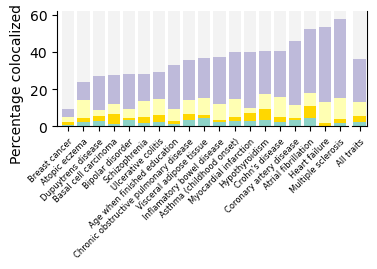

In [27]:
fig, axes = plt.subplots(ncols = 2, figsize=(4, 1.5), gridspec_kw={'width_ratios': [10, 0.5], 'wspace': 0.03})
ax = axes[0]
pos = 0
for trait, row in barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sort_values('molQTLs').iterrows():
    ax.bar([pos], [100], color = cols[8], alpha=0.3)
    ax.bar([pos], [100*row.molQTLs], color=cols[2])
    ax.bar([pos], [100*(row.sQTLs_only + row.sQTL_and_eQTL)], color=cols[1])
    ax.bar([pos], [100*(row.sQTLs_only + row.sQTL_to_eQTL)], color='gold')
    ax.bar([pos], [100*row.sQTLs_only], color=cols[0])
    
    pos += 1
    
xlabels = [#'Rheumatoid arthritis', 
           'Breast cancer', 'Atopic eczema', 'Dupuytrens disease', 'Basal cell carcinoma', 
          'Bipolar disorder', 'Schizophrenia', 'Ulcerative colitis', 'Age when finished education', 
           'Chronic obstructive pulmonary disease', 'Visceral adipose tissue', 'Inflamatory bowel disease',
          'Asthma (childhood onset)', 'Myocardial infarction', 'Hypothyroidism', "Crohn's disease", 'Coronary artery disease',
          'Atrial fibrillation', 'Heart failure', 'Multiple sclerosis']
    
ax.set_xticks(range(19), xlabels, rotation=90)
ax.set_ylabel('Percentage colocalized loci')

axes[1].bar([0], [100], color = cols[8], alpha=0.3)
axes[1].bar([0], [100*barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].molQTLs.mean()], color=cols[2])
axes[1].bar([0], [100*(barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sQTLs_only + barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sQTL_and_eQTL).mean()], color=cols[1])
axes[1].bar([0], [100*(barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sQTLs_only + barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sQTL_to_eQTL).mean()], color='gold')
axes[1].bar([0], [100*barplot_df.loc[[x for x in barplot_df.index if x != 'Rheumatoid_arthritis']].sQTLs_only.mean()], color=cols[0])
ylim = axes[0].get_ylim()
axes[0].set_ylim([0, 62])
axes[1].set_ylim([0, 62])

axes[0].spines[['right', 'top']].set_visible(False)
axes[1].spines[['left', 'top']].set_visible(False)

axes[1].set_yticks([])
axes[1].set_xticks([])
axes[1].set_xticks([0], ['All traits'], rotation=45, ha='right', rotation_mode='anchor', size=6)
axes[0].set_xticks(range(19), xlabels, rotation=45, ha='right', rotation_mode='anchor', size=6)
axes[0].set_xlim((-0.75, 18.5))

In [39]:
hyprcoloc_colocs.groupby('gwas_loci').UP_colocs.max().sum()

np.int64(236)

In [204]:
barplot_df.molQTLs.mean()

np.float64(0.3425630968906209)

In [168]:
hyprcoloc_colocs.loc[(hyprcoloc_colocs.lfc_colocs) | (hyprcoloc_colocs.expr_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    250
Visceral_adipose_tissue_measurement      188
coronary_artery_disease                  155
age_when_finished_full-time_education    136
schizophrenia                            104
Hypothyroidism                           101
GCST004131                                87
GCST004988                                80
atrial_fibrillation                       73
GCST004132                                71
GCST007800                                65
myocardial_infarction                     61
basal_cell_carcinoma                      56
IMSGC2019                                 55
Atopic_eczema                             43
bipolar_disorder                          42
GCST004133                                41
Dupuytrens_disease                        32
heart_failure                             22
Rheumatoid_arthritis                      15
Name: count, dtype: int64

In [169]:
hyprcoloc_colocs.loc[(~hyprcoloc_colocs.lfc_colocs) | (hyprcoloc_colocs.expr_colocs)].groupby('gwas_loci').gwas_trait.first().value_counts()

gwas_trait
Chronic_obstructive_pulmonary_disease    237
Visceral_adipose_tissue_measurement      179
coronary_artery_disease                  151
age_when_finished_full-time_education    121
schizophrenia                            100
Hypothyroidism                            94
GCST004131                                87
GCST004988                                77
atrial_fibrillation                       72
GCST004132                                70
GCST007800                                63
myocardial_infarction                     60
basal_cell_carcinoma                      54
IMSGC2019                                 54
GCST004133                                43
bipolar_disorder                          41
Atopic_eczema                             39
Dupuytrens_disease                        30
heart_failure                             21
Rheumatoid_arthritis                      12
Name: count, dtype: int64

In [659]:
464/3000

0.15466666666666667

In [826]:
import tabix

# Open the Tabix file
tabix_file = tabix.open('../code/resources/gwas/StatsForColoc/Multiple_sclerosis.standardized.txt.tabix.gz')

# Define a function to read the content
def tabix_to_df(tabix_file, chrom, start, end, pheno=False):
    # Fetch data from the tabix file in the desired range
    result = tabix_file.query(chrom, start, end)
    
    # Convert the result to a list of rows (assuming the data is tab-separated)
    rows = [line for line in result]
    
    # Create a DataFrame (adjust columns as per your file structure)
    if pheno:
        cols = ['phe_id', 'phe_chr', 'phe_from', 'phe_to', 'phe_strd', 'n_var_in_cis', 'dist_phe_var', 'var_id', 
         'var_chr', 'var_from', 'var_to', 'nom_pval', 'r_squared', 'slope', 'slope_se', 'best_hit']
    else:
        cols = ["gwas_trait", "chrom", "pos", "beta", "se", "a1", "a2"]
    df = pd.DataFrame(rows, columns=cols)  # Add correct column names
    return df

# Example: Reading data from a specified region
chrom = 'chr12'
start = int(6330843-2e5)
end = int(6330843+2e5)
df = tabix_to_df(tabix_file, chrom, start, end)

# Display the resulting dataframe
print(df.head())

                    gwas_trait  chrom      pos                  beta  \
0  chr12_6330843_N_N_IMSGC2019  chr12  6130884  0.012718772407774612   
1  chr12_6330843_N_N_IMSGC2019  chr12  6132280  0.010841023177874769   
2  chr12_6330843_N_N_IMSGC2019  chr12  6132541  0.011533235813673085   
3  chr12_6330843_N_N_IMSGC2019  chr12  6133074   0.01143437762566317   
4  chr12_6330843_N_N_IMSGC2019  chr12  6133093  0.011928570865273812   

                     se a1 a2  
0  0.017241241656458874  T  C  
1  0.017835606986328193  G  A  
2  0.017905516793835907  T  C  
3  0.017901799412234135  G  A  
4  0.018041469021444424  G  T  


In [661]:
hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.UP_colocs)].iloc[1]#.traits

iteration                                                                     2
traits                        chr12_111494996_N_N_GCST004131, Colon-Transver...
posterior_prob                                                           0.9676
regional_prob                                                            0.9893
candidate_snp                                           chr12_111427245_C_G_b38
posterior_explained_by_snp                                                0.346
dropped_trait                                                               NaN
gwas_trait                                                           GCST004131
gwas_colocs                                                                True
UP_colocs                                                                  True
expr_colocs                                                               False
lfc_colocs                                                                 True
lfc_other_colocs                        

In [827]:
def GetUpIntrons(traits, gwas_trait):
    traits = traits.split(', ')
    up_traits = [x for x in traits if ':UP:' in x]
    tissues = []
    introns = []
    genes = []
    for up in up_traits:
        tissues.append(up.split('.')[0])
        intron = ':'.join(up.split('_N_N_')[1].split(':')[:-1])
        introns.append(intron)
        genes.append(up.split(':')[-1].split('.')[0])
    out_df = pd.DataFrame()
    out_df['tissues'] = tissues
    out_df['intron'] = introns
    out_df['gene'] = genes
    return out_df

def GetTables(tissue, intron, gene, gwas_loci):
    chrom = gwas_loci.split('_')[0]
    pos = int(gwas_loci.split('_')[1])
    start = int(pos - 5e5)
    end = int(pos + 5e5)
    
    
    lc_file = tabix.open(f"../code/results/coloc/qtls/{tissue}/leafcutter.NominalPass/{chrom}.txt.tabix.gz")
    lc_df = tabix_to_df(lc_file, chrom, start, end, pheno=True)

    exp_file = tabix.open(f"../code/results/eqtl/GTEx/{tissue}/cis_100000/nom/{chrom}.txt.gz")
    exp_df = tabix_to_df(exp_file, chrom, start, end, pheno=True)
    
    return lc_df, exp_df

def GetZ(lc_df, exp_df, intron, gene, gwas_loci, variant):
    
    variant_pos = int(variant.split('_')[1])
    intron_start = int(intron.split(':')[1])
    intron_end = int(intron.split(':')[2])
    
#     if (variant_pos <= (intron_end +1e4)) & (variant_pos >= (intron_start -1e4)):

    lc_row = lc_df.loc[(lc_df.phe_id == f'{intron}:{gwas_loci}') & (lc_df.var_id == variant)]
    lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]

    exp_row = exp_df.loc[(exp_df.phe_id.apply(lambda x: gene in x)) & (exp_df.var_id == variant)]
    exp_z = float(exp_row.slope)/float(exp_row.slope_se)
#     else:
#         lc_z = np.nan
#         exp_z = np.nan
    return lc_z, exp_z

def GetEffects(coloc_row):
    traits = coloc_row.traits
    gwas_loci = coloc_row.gwas_loci
    variant = coloc_row.candidate_snp
    up_df = GetUpIntrons(traits, gwas_loci)
    z_list = []
    for idx, row in up_df.iterrows():
        tissue = row.tissues
        intron = row.intron
        gene = row.gene
#         print(intron)
        
        lc_df, exp_df = GetTables(tissue, intron, gene, gwas_loci)
        lc_z, exp_z = GetZ(lc_df, exp_df, intron, gene, gwas_loci, variant)
        z_list.append((lc_z, exp_z))
#         exp_z_list.append(exp_z)
        
    return z_list#, exp_z_list

In [828]:
lc_aorta

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
0,chr12:6330711:6333068:clu_22761_-:UP:chr12_633...,chr12,5830844,6830843,-,2583,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.511495,0.00249546,-0.0607041,0.0922736,0
1,chr12:6330711:6333068:clu_22761_-:UP:chr12_638...,chr12,5883935,6883934,-,2544,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.511495,0.00249546,-0.0607041,0.0922736,0
2,chr12:6330711:6333068:clu_22761_-:UP:chr12_638...,chr12,5884186,6884185,-,2545,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.511495,0.00249546,-0.0607041,0.0922736,0
3,chr12:6460938:6462033:clu_21699_+:PR:chr12_633...,chr12,5830844,6830843,+,2583,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.956132,1.75412e-05,-0.00517279,0.0939007,0
4,chr12:6460938:6462033:clu_21699_+:PR:chr12_638...,chr12,5883935,6883934,+,2544,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.956132,1.75412e-05,-0.00517279,0.0939007,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12523,chr12:6461390:6462033:clu_21699_+:NE:chr12_638...,chr12,5883935,6883934,+,2544,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.0413429,0.023838,0.230216,0.112005,0
12524,chr12:6461390:6462033:clu_21699_+:NE:chr12_638...,chr12,5884186,6884185,+,2545,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.0413429,0.023838,0.230216,0.112005,0
12525,chr12:6462842:6464889:clu_22766_-:PR:chr12_633...,chr12,5830844,6830843,-,2583,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.215286,0.00886202,-0.0869383,0.0699019,0
12526,chr12:6462842:6464889:clu_22766_-:PR:chr12_638...,chr12,5883935,6883934,-,2544,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.215286,0.00886202,-0.0869383,0.0699019,0


In [829]:
lc_aorta['cluster'] = lc_aorta.phe_id.apply(lambda x: x.split(':')[3])
lc_aorta['intron_type'] = lc_aorta.phe_id.apply(lambda x: x.split(':')[4])

In [669]:
cluster_type = pd.DataFrame(lc_aorta.groupby('cluster').intron_type.unique().apply(lambda x: ', '.join(x)))
cluster_type.columns = ['cluster_type']
lc_aorta = lc_aorta.merge(cluster_type, left_on='cluster', right_index=True)

MergeError: Passing 'suffixes' which cause duplicate columns {'cluster_type_x'} is not allowed.

In [674]:
lc_z

[np.float64(6.529498225832002),
 np.float64(-4.715460857433132),
 np.float64(8.393893105855867),
 np.float64(-3.4305095303559794),
 np.float64(-5.5474357660200555),
 np.float64(-4.723049793693977),
 np.float64(-5.400210868876101),
 np.float64(4.648293921346341),
 np.float64(-4.854151171214682),
 np.float64(-5.904737702443284),
 np.float64(-5.1364692121868645),
 np.float64(-5.259806514357863),
 np.float64(4.110234609339968),
 np.float64(9.248129199961713),
 np.float64(-6.778148337688922),
 np.float64(-4.4591367751055175),
 np.float64(-6.067384127562765),
 np.float64(-4.1687323925334585),
 np.float64(-4.720494392352842),
 np.float64(-7.622130446594792)]

In [675]:
exp_z

[np.float64(3.9484488445987442),
 np.float64(1.3216097212553006),
 np.float64(-0.269760250217321),
 np.float64(1.259883318310726),
 np.float64(-1.756564626481004),
 np.float64(6.519091934651199),
 np.float64(1.7792731866305596),
 np.float64(-1.9120882390866618),
 np.float64(-0.03696973764201517),
 np.float64(4.043524316099848),
 np.float64(-0.5823730749584727),
 np.float64(8.485999289348019),
 np.float64(-2.908083441981747),
 np.float64(-0.3250406857237026),
 np.float64(-9.200680255582142),
 np.float64(-11.101019954841695),
 np.float64(-10.385554196880191),
 np.float64(-4.797709593138072),
 np.float64(6.449959682421536),
 np.float64(-6.758226042851612)]

In [830]:
lc_z = []
exp_z = []

for idx, row in hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.UP_colocs)].iterrows():
    try:
        z = GetEffects(row)
        lc_z.append(np.mean([z_[0] for z_ in z]))
        exp_z.append(np.mean([z_[1] for z_ in z]))
        print(idx)
        print(z)
        
        print('########')
    except:
        continue

/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp_z = float(exp_row.slope)/float(exp_row.slope_se)


914
[(-5.884035727528313, 7.337019401922392), (-4.436009023490302, 9.658414865934683), (-5.303716759723668, 4.698221392331051), (-5.154356105129532, 1.3187242107589208), (-5.449410580150984, 8.04629800263669), (-6.269297681536536, 11.06058835558412), (-4.56824583281479, 7.803654378048497)]
########


/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp_z = float(exp_row.slope)/float(exp_row.slope_se)


5158
[(4.884364544721604, 4.034133192625797), (6.245507254550226, 3.8543486613648064), (7.836049802412466, 3.7439058861534735), (7.152071301643715, 4.161407638250901), (6.031139875129101, 2.534208032935903), (8.766755308205086, 7.928569482659984), (7.372909388815037, 2.282907681605883), (5.731196376199989, 1.499399908951703), (6.627245405951043, 3.577446199314885), (4.896348197825548, 2.470101717185736), (6.072450929730882, 3.64598371602478), (4.838442847995228, 0.8418727174146556), (4.778452598437439, 5.1426282802374095)]
########


/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp_z = float(exp_row.slope)/float(exp_row.slope_se)


...

/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp_z = float(exp_row.slope)/float(exp_row.slope_se)


62300
[(4.9174069889718215, -1.2991627242702848), (6.163310601421013, 0.3413255622805051)]
########


/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  exp_z = float(exp_row.slope)/float(exp_row.slope_se)


64270
[(4.441805073976871, -2.2491751345691777)]
########


/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]
/tmp/ipykernel_251187/4014174296.py:42: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lc_z = float(lc_row.slope)/float(lc_row.slope_se) #[['nom_pval', 'slope','slope_se']]


In [832]:
hyprcoloc.iloc[6547].traits

'chr12_110796494_N_N_schizophrenia, Esophagus-GastroesophagealJunction.leafcutter_N_N_chr12:110376216:110381751:clu_24214_-:PR:ENSG00000196510.12, Muscle-Skeletal.leafcutter_N_N_chr12:110377617:110377704:clu_24435_-:UP:ENSG00000196510.12, Adipose-Visceral_Omentum.expression_N_N_ENSG00000111237, AdrenalGland.expression_N_N_ENSG00000111237, Artery-Aorta.expression_N_N_ENSG00000111237, Artery-Tibial.expression_N_N_ENSG00000111229, Brain-Anteriorcingulatecortex_BA24.expression_N_N_ENSG00000111237, Brain-Caudate_basalganglia.expression_N_N_ENSG00000111237, Brain-CerebellarHemisphere.expression_N_N_ENSG00000111237, Brain-Cortex.expression_N_N_ENSG00000111237, Brain-Hippocampus.expression_N_N_ENSG00000111237, Brain-Hypothalamus.expression_N_N_ENSG00000111237, Brain-Nucleusaccumbens_basalganglia.expression_N_N_ENSG00000111237, Brain-Putamen_basalganglia.expression_N_N_ENSG00000111237, Brain-Spinalcord_cervicalc-1.expression_N_N_ENSG00000111237, Brain-Substantianigra.expression_N_N_ENSG00000196

In [802]:
93187146 - 93282126

-94980

In [727]:
6345932 - 6333068

12864

In [456]:
lc_aorta.iloc[0].phe_id

'chr12:6330711:6333068:clu_23281_-:UP:chr12_6330843_N_N_IMSGC2019'

In [728]:
lc_file = tabix.open("../code/results/coloc/qtls/Brain-FrontalCortex_BA9/leafcutter.NominalPass/chr12.txt.tabix.gz")
lc_aorta = tabix_to_df(lc_file, chrom, start, end, pheno=True)

exp_file = tabix.open("../code/results/eqtl/GTEx/Brain-FrontalCortex_BA9/cis_100000/nom/chr12.txt.gz")
exp_aorta = tabix_to_df(exp_file, chrom, start, end, pheno=True)

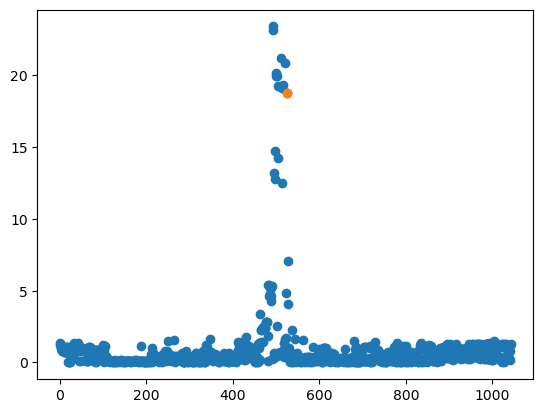

In [397]:
plt.scatter(range(len(np.array(np.log10(lc_aorta.loc[
    (lc_aorta.phe_id == 'chr12:6330711:6333068:clu_23281_-:UP:chr12_6330843_N_N_IMSGC2019')].nom_pval.astype(float))))), -np.array(np.log10(lc_aorta.loc[
    (lc_aorta.phe_id == 'chr12:6330711:6333068:clu_23281_-:UP:chr12_6330843_N_N_IMSGC2019')].nom_pval.astype(float))))

plt.scatter([525], [-np.log10(1.5469e-19)])

In [379]:

hyprcoloc.loc[(hyprcoloc.gwas_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.expr_colocs)].traits.iloc[1]

'chr12_6330843_N_N_IMSGC2019, Brain-Anteriorcingulatecortex_BA24.leafcutter_N_N_chr12:6330711:6333068:clu_22335_-:UP:ENSG00000067182.7, Brain-Cortex.leafcutter_N_N_chr12:6330711:6333068:clu_23281_-:UP:ENSG00000067182.7, Brain-FrontalCortex_BA9.leafcutter_N_N_chr12:6330711:6333068:clu_22761_-:UP:ENSG00000067182.7, Brain-Spinalcord_cervicalc-1.leafcutter_N_N_chr12:6330711:6333068:clu_22141_-:UP:ENSG00000067182.7, WholeBlood.leafcutter_N_N_chr12:6330711:6330852:clu_22118_-:PR:ENSG00000067182.7, Cells-EBV-transformedlymphocytes.leafcutter_N_N_chr12:6330711:6333068:clu_20137_-:UP:ENSG00000067182.7, Muscle-Skeletal.leafcutter_N_N_chr12:6330711:6330852:clu_23610_-:PR:ENSG00000067182.7, Spleen.leafcutter_N_N_chr12:6330711:6333068:clu_22319_-:UP:ENSG00000067182.7, WholeBlood.expression_N_N_ENSG00000008323'

In [390]:
idx

525

In [392]:
lc_aorta.loc[
    (lc_aorta.phe_id == 'chr12:6330711:6333068:clu_23281_-:UP:chr12_6330843_N_N_IMSGC2019') & (lc_aorta.var_id == 'chr12_6345932_T_G_b38')].nom_pval

16275    1.5469e-19
Name: nom_pval, dtype: object

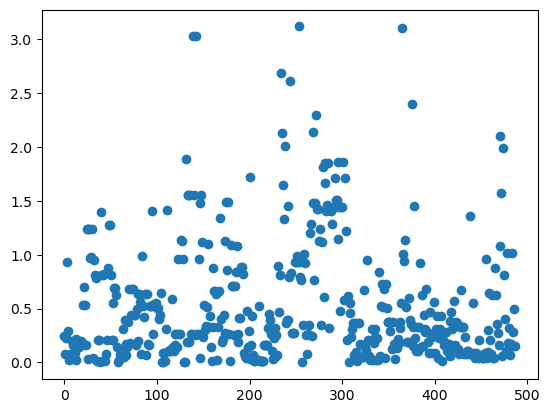

In [402]:
plt.scatter(range(len(np.array(-np.log10(exp_aorta.loc[
   (exp_aorta.phe_id == 'ENSG00000067182.8')].nom_pval.astype(float))))), np.array(-np.log10(exp_aorta.loc[
   (exp_aorta.phe_id == 'ENSG00000067182.8')].nom_pval.astype(float))))

In [352]:
0.0513067/0.0353283

1.4522832969602273

In [192]:
lc_aorta.loc[
    (lc_aorta.phe_id == 'chr11:5666081:5678203:clu_21271_-:UP:chr11_5679844_N_N_coronary_artery_disease') ].shape

(2029, 16)

In [193]:
exp_aorta.loc[(exp_aorta.phe_id.apply(lambda x: 'ENSG00000132256' in x)) ].shape

(2029, 16)

In [420]:
lc_aorta

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
0,chr12:6330711:6333068:clu_23281_-:UP:chr12_633...,chr12,5830844,6830843,-,2583,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.063032,0.0169205,-0.149817,0.0801493,0
1,chr12:6330711:6333068:clu_23281_-:UP:chr12_638...,chr12,5883935,6883934,-,2544,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.063032,0.0169205,-0.149817,0.0801493,0
2,chr12:6330711:6333068:clu_23281_-:UP:chr12_638...,chr12,5884186,6884185,-,2545,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.063032,0.0169205,-0.149817,0.0801493,0
3,chr12:6460938:6462033:clu_22197_+:PR:chr12_633...,chr12,5830844,6830843,+,2583,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.174629,0.00905867,0.118063,0.086668,0
4,chr12:6460938:6462033:clu_22197_+:PR:chr12_638...,chr12,5883935,6883934,+,2544,0,chr12_6130884_T_C_b38,chr12,6130884,6130884,0.174629,0.00905867,0.118063,0.086668,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32359,chr12:6823763:6825483:clu_22214_+:PR:chr12_638...,chr12,5884186,6884185,+,2545,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.432203,0.00304176,0.0794165,0.100911,0
32360,chr12:6868509:6868863:clu_22224_+:PR:chr12_638...,chr12,5883935,6883934,+,2544,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.0275663,0.02369,0.203677,0.0917711,0
32361,chr12:6868509:6868863:clu_22224_+:PR:chr12_638...,chr12,5884186,6884185,+,2545,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.0275663,0.02369,0.203677,0.0917711,0
32362,chr12:6872997:6873245:clu_23323_-:PR:chr12_638...,chr12,5883935,6883934,-,2544,0,chr12_6530815_C_G_b38,chr12,6530815,6530815,0.611734,0.00127157,0.0243048,0.0478078,0


In [194]:
x = np.array(lc_aorta.loc[
    (lc_aorta.phe_id == 'chr11:5666081:5678203:clu_21271_-:UP:chr11_5679844_N_N_coronary_artery_disease') ].slope.astype(float))
y = np.array(exp_aorta.loc[(exp_aorta.phe_id.apply(lambda x: 'ENSG00000132256' in x)) ].slope.astype(float))

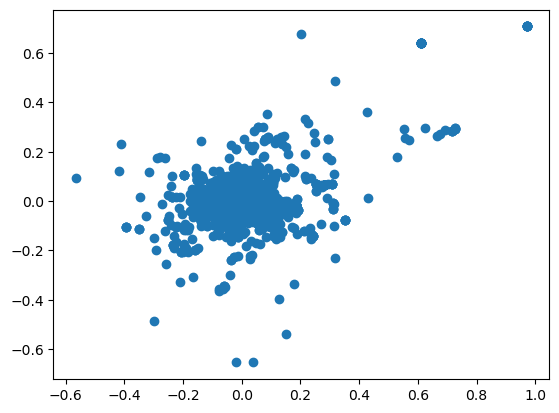

In [196]:
plt.scatter(x, y)

In [ ]:
'chr5_177371039_N_N_GCST004131, 
Adipose-Visceral_Omentum.leafcutter_N_N_chr5:177371396:177371872:clu_11773_+:UP:ENSG00000169220.17, 
                    Colon-Transverse.leafcutter_N_N_chr5:177371396:177371872:clu_11662_+:UP:ENSG00000169220.17, 
            Esophagus-Mucosa.leafcutter_N_N_chr5:177307703:177307780:clu_12277_-:PR:ENSG00000213347.10, Pituitary.leafcutter_N_N_chr5:177371396:177371872:clu_11694_+:UP:ENSG00000169220.17'

In [594]:
chrom = 'chr12'
start = int(111494996-5e5)
end = int(111494996+5e5)

lc_file = tabix.open("../code/results/coloc/qtls/Colon-Transverse/leafcutter.NominalPass/chr12.txt.tabix.gz")
lc_aorta = tabix_to_df(lc_file, chrom, start, end, pheno=True)

exp_file = tabix.open("../code/results/coloc/qtls/Colon-Transverse/expression.NominalPass/chr12.txt.tabix.gz")
exp_aorta = tabix_to_df(exp_file, chrom, start, end, pheno=True)

In [144]:
'chr12_111494996_N_N_GCST004131, Colon-Transverse.leafcutter_N_N_chr12:111470742:111485712:clu_25124_-:UP:ENSG00000204842.14'


,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
0,chr5:177371396:177371872:clu_11662_+:UP:chr5_1...,chr5,176847403,177847402,+,1484,0,chr5_176876670_A_G_b38,chr5,176876670,176876670,0.242523,0.00373001,-0.0735969,0.0628714,0
1,chr5:177371396:177371872:clu_11662_+:UP:chr5_1...,chr5,176863162,177863161,+,1461,0,chr5_176876670_A_G_b38,chr5,176876670,176876670,0.242523,0.00373001,-0.0735969,0.0628714,0
2,chr5:177371396:177371872:clu_11662_+:UP:chr5_1...,chr5,176865557,177865556,+,1463,0,chr5_176876670_A_G_b38,chr5,176876670,176876670,0.242523,0.00373001,-0.0735969,0.0628714,0
3,chr5:177371396:177371872:clu_11662_+:UP:chr5_1...,chr5,176871040,177871039,+,1458,0,chr5_176876670_A_G_b38,chr5,176876670,176876670,0.242523,0.00373001,-0.0735969,0.0628714,0
4,chr5:177604541:177605044:clu_11670_+:PR:chr5_1...,chr5,176847403,177847402,+,1484,0,chr5_176876670_A_G_b38,chr5,176876670,176876670,0.791231,0.000191698,0.0167905,0.0633829,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,chr5:177713916:177716344:clu_12506_-:NE:chr5_1...,chr5,176871040,177871039,-,1458,0,chr5_177865099_A_G_b38,chr5,177865099,177865099,0.175922,0.00499907,-0.131122,0.0966949,0
45180,chr5:177951956:177957608:clu_11675_+:IN:chr5_1...,chr5,176965349,177965348,+,1599,0,chr5_177865099_A_G_b38,chr5,177865099,177865099,0.705156,0.000391616,-0.0518755,0.136996,0
45181,chr5:177951956:177957608:clu_11675_+:IN:chr5_1...,chr5,177003171,178003170,+,1711,0,chr5_177865099_A_G_b38,chr5,177865099,177865099,0.705156,0.000391616,-0.0518755,0.136996,0
45182,chr5:177953292:177957608:clu_11675_+:IN:chr5_1...,chr5,176965349,177965348,+,1599,0,chr5_177865099_A_G_b38,chr5,177865099,177865099,0.669684,0.000497745,0.0555577,0.130134,0


In [183]:
x = np.array(lc_aorta.loc[
    (lc_aorta.phe_id == 'chr12:111470742:111485712:clu_25124_-:UP:chr12_111494996_N_N_GCST004131') ].slope.astype(float))
y = np.array(exp_aorta.loc[(exp_aorta.phe_id.apply(lambda x: 'ENSG00000204842' in x
                                                  ) & (exp_aorta.phe_id.apply(
    lambda x: 'chr12_111494996_N_N_GCST004131' in x))) ].slope.astype(float))

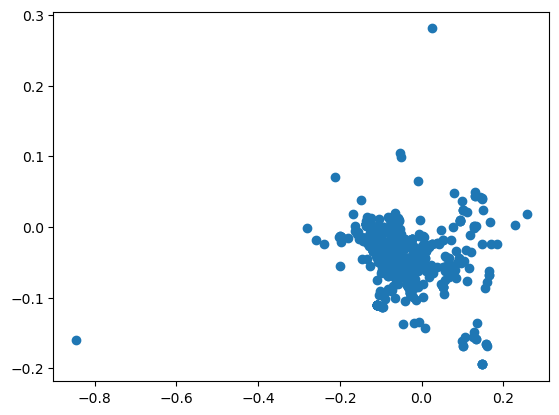

In [184]:
plt.scatter(x, y)

In [186]:
lc_aorta.loc[
    (lc_aorta.phe_id == 'chr12:111470742:111485712:clu_25124_-:UP:chr12_111494996_N_N_GCST004131') & (
        lc_aorta.var_id == 'chr12_111427245_C_G_b38')]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
2560,chr12:111470742:111485712:clu_25124_-:UP:chr12...,chr12,110994997,111994996,-,1012,0,chr12_111427245_C_G_b38,chr12,111427245,111427245,3.43488e-06,0.0572732,-0.201436,0.0427182,1


In [188]:
exp_aorta.loc[(exp_aorta.var_id == 'chr12_111427245_C_G_b38') & (exp_aorta.phe_id.apply(lambda x: 'ENSG00000204842' in x) & (exp_aorta.phe_id.apply(lambda x: 'chr12_111494996_N_N_GCST004131' in x))) 
                          ]

,phe_id,phe_chr,phe_from,phe_to,phe_strd,n_var_in_cis,dist_phe_var,var_id,var_chr,var_from,var_to,nom_pval,r_squared,slope,slope_se,best_hit
17829,ENSG00000204842.18:chr12_111494996_N_N_GCST004131,chr12,110994997,111994996,-,1012,0,chr12_111427245_C_G_b38,chr12,111427245,111427245,0.611675,0.00070493,-0.0138499,0.0272571,0


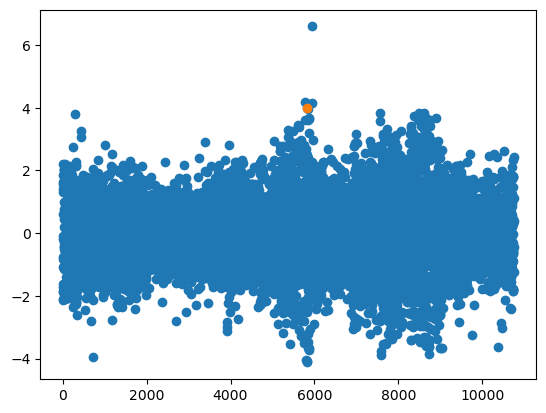

In [62]:
plt.scatter(range(len(np.array(df.beta.astype(float)/df.se.astype(float)))), np.array(df.beta.astype(float)/df.se.astype(float)))
plt.scatter([5823], [0.03675553/0.0091871846])

In [47]:
0.06214997/0.0094310250000000009

6.589948600496764

In [43]:
x

['chr11_5679844_N_N_coronary_artery_disease',
 'chr11',
 '5679771',
 '-0.00770473',
 '0.0052546703',
 'c',
 't']

In [685]:
import gzip
def clearn_leafcutter_pheono(leafcutter_file, output_file):
    counts = 0
    with gzip.open(leafcutter_file, 'rb') as fh:
        with gzip.open(output_file, 'wb') as fh2:
            for line in fh:
                if counts == 0:
                    row = line.decode().rstrip().split(' ')
                    out_row = (' '.join([x.split('.')[0] for x in row]) + '\n').encode()
                else:
                    out_row = line
                fh2.write(out_row)
                counts += 1
        
lf_file = '/project/yangili1/cfbuenabadn/SpliFi/code/results/pheno/noisy/GTEx/WholeBlood/leafcutter_perind.counts.gz'
clean_lf = 'WholeBlood.leafcutter_perind.counts.gz'
clearn_leafcutter_pheono(lf_file, clean_lf)

In [691]:
with open('../../quickSashimi/leafcutter.phen_chr16', 'rt') as fh:
    x = fh.readline()
    

In [693]:
x.rstrip().split('\t')

['#Chr',
 'start',
 'end',
 'pid',
 'gid',
 'strand',
 'GTEX-111YS',
 'GTEX-1122O',
 'GTEX-1128S',
 'GTEX-113IC',
 'GTEX-113JC',
 'GTEX-117XS',
 'GTEX-117YW',
 'GTEX-1192W',
 'GTEX-1192X',
 'GTEX-11DXX',
 'GTEX-11DXZ',
 'GTEX-11DYG',
 'GTEX-11EI6',
 'GTEX-11EM3',
 'GTEX-11EMC',
 'GTEX-11EQ8',
 'GTEX-11EQ9',
 'GTEX-11GS4',
 'GTEX-11GSO',
 'GTEX-11GSP',
 'GTEX-11I78',
 'GTEX-11LCK',
 'GTEX-11NUK',
 'GTEX-11NV4',
 'GTEX-11O72',
 'GTEX-11OF3',
 'GTEX-11ONC',
 'GTEX-11P7K',
 'GTEX-11P81',
 'GTEX-11P82',
 'GTEX-11PRG',
 'GTEX-11TT1',
 'GTEX-11TTK',
 'GTEX-11TUW',
 'GTEX-11UD2',
 'GTEX-11VI4',
 'GTEX-11WQC',
 'GTEX-11WQK',
 'GTEX-11XUK',
 'GTEX-11ZTS',
 'GTEX-11ZTT',
 'GTEX-11ZU8',
 'GTEX-11ZUS',
 'GTEX-11ZVC',
 'GTEX-1211K',
 'GTEX-12126',
 'GTEX-1212Z',
 'GTEX-12584',
 'GTEX-12696',
 'GTEX-1269C',
 'GTEX-12C56',
 'GTEX-12KS4',
 'GTEX-12WSD',
 'GTEX-12WSE',
 'GTEX-12WSF',
 'GTEX-12WSG',
 'GTEX-12WSH',
 'GTEX-12WSI',
 'GTEX-12WSJ',
 'GTEX-12WSK',
 'GTEX-12WSL',
 'GTEX-12WSM',
 'GTEX-12WSN',
 

In [3]:
import os

In [724]:
samples = [x.split('.')[0] for x in os.listdir('/project/yangili1/cfbuenabadn/bigwigs//Brain-FrontalCortex_BA9/') if x.endswith('bw')]

In [707]:
chr12:6330711:6333068

In [ ]:
Brain-FrontalCortex_BA9.leafcutter_N_N_chr12:6330711:6333068:clu_22761_-:UP:ENSG00000067182.7

In [725]:
clu = 'clu_22761_-'
with open('../../AggregateGenometracks/qtl_tracks/clu_22761_-.junctions.bed', 'w') as bed:
    with open('../../sashimi/leafcutter.phen_chr12', 'rt') as fh:
        header = fh.readline().rstrip().split('\t')
        bed_header = header[:6]
        samples_ = header[6:]
        samples = list(pd.Index(samples_).intersection(pd.Index(samples)))
        out_header = '\t'.join(bed_header + samples) + '\n'
        bed.write(out_header)
        
        for line in fh:
            row = line.rstrip().split('\t')
            bed_data = row[:6]
            intron = bed_data[3]
            if f':{clu}:' in intron:
                out_samples = [str(float(row[samples_.index(x)+6])*100) for x in samples]
                out_row = '\t'.join(bed_data + out_samples) + '\n'
                bed.write(out_row)
        
#         [samples_.index(x) for x in samples]
# #         break
#         'clu_28146_-'

In [709]:
[samples_.index(x) for x in samples]

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 81,
 82,
 83,
 90,
 94,
 95,
 99,
 103,
 104,
 109,
 110,
 111,
 113,
 114,
 115,
 117,
 119,
 123,
 129,
 132,
 133,
 134,
 139,
 146,
 150,
 152,
 153]

In [706]:
pd.Index(samples_).intersection(pd.Index(samples))

Index(['GTEX-111YS', 'GTEX-1122O', 'GTEX-1128S', 'GTEX-113IC', 'GTEX-113JC',
       'GTEX-117XS', 'GTEX-117YW', 'GTEX-1192W', 'GTEX-1192X', 'GTEX-11DXX',
       ...
       'GTEX-148VI', 'GTEX-14AS3', 'GTEX-14BIM', 'GTEX-14BIN', 'GTEX-14BMU',
       'GTEX-14DAQ', 'GTEX-14H4A', 'GTEX-14JG6', 'GTEX-14LLW', 'GTEX-14LZ3'],
      dtype='object', length=106)

In [9]:
import pyBigWig
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

bw = pyBigWig.open("../code/resources/GTEx/BigWig/Heart_Atrial_Appendage/GTEX-11DXX-0526-SM-5PNVR.bw")

# Get chromosome sizes
chrom_sizes = bw.chroms()

# Get values for a specific region
chrom_sizes = bw.chroms()

# Get values for a specific region
values = bw.values("chr12", 6330711, 6333068)

# Get statistics for a specific region
stats = bw.stats("chr12", 6330711, 6333068)

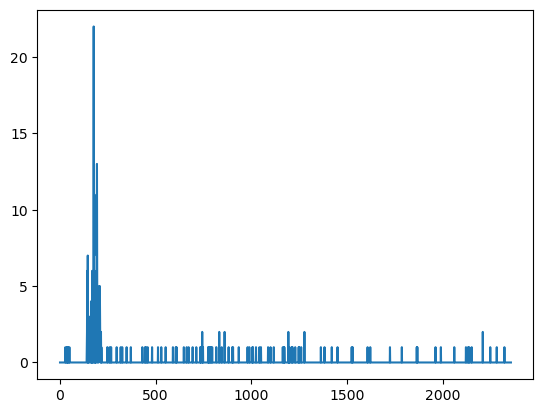

In [10]:
plt.plot(np.array(values))

In [9]:
 
np.sum(~np.isnan(np.array(values)))

np.int64(2331)

In [6]:
93158814 - 93156483

2331

In [7]:
chr16_72018449_N_N_coronary_artery_disease, Liver.leafcutter_N_N_chr16:72017106:72020401:clu_26029_+:UP:ENSG00000102967.11, 
                    WholeBlood.leafcutter_N_N_chr16:72017106:72020401:clu_27338_+:UP:ENSG00000102967.11

SyntaxError: only single target (not tuple) can be annotated (4068097547.py, line 1)

In [ ]:
sbatch: Verification: ***PASSED***
Submitted job 9244 with external jobid '27127669'.
[Sat Dec 21 23:46:49 2024]
Error in rule SelectSignificantTraitsForGWASColoc:
    jobid: 27758
    input: results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.qqnorm.bed.gz, results/coloc/qtls/Skin-SunExposed_Lowerleg/expression.PermutationPass.FDR_Added.txt.gz
    output: results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed, results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed.gz, results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed.gz.tbi
    log: /scratch/midway3/cnajar/logs/QTLs/get_significant_traits_.ForGWASColoc.Skin-SunExposed_Lowerleg/chr12.expression.log (check log file(s) for error details)
    shell:

        python scripts/filter_permutation_pass_forGWAScoloc.py results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.qqnorm.bed.gz results/coloc/qtls/Skin-SunExposed_Lowerleg/expression.PermutationPass.FDR_Added.txt.gz results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed &> /scratch/midway3/cnajar/logs/QTLs/get_significant_traits_.ForGWASColoc.Skin-SunExposed_Lowerleg/chr12.expression.log;
        (bgzip results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed -c > results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed.gz) &>> /scratch/midway3/cnajar/logs/QTLs/get_significant_traits_.ForGWASColoc.Skin-SunExposed_Lowerleg/chr12.expression.log
        tabix -p bed results/coloc/data/Skin-SunExposed_Lowerleg/chr12.expression.ForGWASColoc.sorted.significant_only.qqnorm.bed.gz &>> /scratch/midway3/cnajar/logs/QTLs/get_significant_traits_.ForGWASColoc.Skin-SunExposed_Lowerleg/chr12.expression.log

        (one of the commands exited with non-zero exit code; note that snakemake uses bash strict mode!)
    cluster_jobid: 27127595

Error executing rule SelectSignificantTraitsForGWASColoc on cluster (jobid: 27758, external: 27127595, jobscript: /project/yangili1/cfbuenabadn/leafcutter2_paper/code/.snakemake/tmp.98u8av9r/snakejob.SelectSignificantTraitsForGWASColoc.27758.sh). For error details see the cluster log and the log files of the involved rule(s).

[Sat Dec 21 23:46:49 2024]
rule tabixNominalPassQTLResultsForGWASColoc:
    input: results/coloc/qtls/Liver/leafcutter.NominalPass/chr20.txt.gz
    output: results/coloc/qtls/Liver/leafcutter.NominalPass/chr20.txt.tabix.gz, results/coloc/qtls/Liver/leafcutter.NominalPass/chr20.txt.tabix.gz.tbi
    log: /scratch/midway2/cnajar/logs/tabixNominalPassQTLResults/Liver/leafcutter.NominalPass/chr20.log
    jobid: 9580
    reason: Input files updated by another job: results/coloc/qtls/Liver/leafcutter.NominalPass/chr20.txt.gz
    wildcards: tissue=Liver, pheno=leafcutter, chrom=chr20

In [2]:
import pandas as pd
import gzip
import sys

arguments = sys.argv
input_bed = "results/coloc/data/Skin-SunExposed_Lowerleg/{chrom}.{pheno}.ForGWASColoc.sorted.qqnorm.bed.gz"
input_permutation = arguments[2]
output = arguments[3]

permutation = pd.read_csv(input_permutation, sep=' ')

####################################
permutation['cluster'] = permutation.phe_id.apply(lambda x: x.split(':')[3])
q_df = pd.DataFrame(permutation.groupby('cluster').q.min())

IndexError: list index out of range

In [ ]:
eno/GTEx/WholeBlood/chr16.vcf.gz 
--bed results/coloc/data/WholeBlood/chr16.leafcutter.ForGWASColoc.sorted.significant_only.qqnorm.bed.gz 
--cov results/coloc/data/WholeBlood/chr16.leafcutter.ForGWASColoc.sorted.qqnorm.bed.pca  
--out results/coloc/qtls/WholeBlood/leafcutter.NominalPass_chunks/chr16.0.txt             -
-window 1 &> /scratch/midway2/cnajar/logs/NominalQTL_GTEx_WholeBlood_leafcutter_chr16.0.log
        if [ ! -f results/coloc/qtls/WholeBlood/leafcutter.NominalPass_chunks/chr16.0.txt ]
        then
            touch results/coloc/qtls/WholeBlood/leafcutter.NominalPass_chunks/chr16.0.txt
        fi

        (one of the commands exited with non-zero exit code; note that snakemake uses bash strict mode!)
    cluster_jobid: 27150142

Error executing rule coloc_QTLs_nominal on cluster (jobid: 15116, external: 27150142, jobscript: /project/yangili1/cfbuenabadn/leafcutter2_paper/code/.snakemake/tmp.6lqhg8v3/snakejob.coloc_QTLs_nominal.15116.sh). For error details see the cluster log and the log files of the involved rule(s).
----------------------------------------
Exception happened during processing of request from ('127.0.0.1', 38770)
Traceback (most recent call last):
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/socketserver.py", line 720, in __init__
    self.handle()
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/http/server.py", line 427, in handle
    self.handle_one_request()
  File "/scratch/midway3/cnajar/anaconda3/envs/ebpmf/lib/python3.8/http/server.py", line 415, in handle_one_request
    method()
  File "/home/cnajar/.config/snakemake/slurm/slurm-sidecar.py", line 213, in do_GET

bedFiles="/project2/yangili1/GTEx_v8/bedGraph/Brain_Putamen_basal_ganglia/GTEX-1CB4H-0011-R7b-SM-CJI27.bed.gz /project2/yangili1/GTEx_v8/bedGraph/Brain_Putamen_basal_ganglia/GTEX-13FHO-0011-R7b-SM-5LZXD.bed.gz"

numJobs=0
maxJobs=8

for f in ${bedFiles[@]}; do
    tmpf=resources/GTEx/BigWig/Brain_Putamen_basal_ganglia/$(basename "$f" .bed.gz).tmp.bed &>> logs/bed2bw.Brain_Putamen_basal_ganglia.log
    tmp_sortedf=resources/GTEx/BigWig/Brain_Putamen_basal_ganglia/$(basename "$f" .bed.gz).tmp.sorted.bed &>> logs/bed2bw.Brain_Putamen_basal_ganglia.log
    outf=resources/GTEx/BigWig/Brain_Putamen_basal_ganglia/$(basename $f .bed.gz).bw &>> logs/bed2bw.Brain_Putamen_basal_ganglia.log

    if [[ $numJobs -le $maxJobs ]]; then
        echo scripts/bedGraphToBigWig $f ...
        (bgzip -f -d -c $f > $tmpf && bedtools sort -i $tmpf > $tmp_sortedf && scripts/bedGraphToBigWig $tmp_sortedf resources/hg38_w_chrEBV.chrom.sizes $outf && rm $tmpf && rm $tmp_sortedf &
        numJobs=$((numJobs + 1))) &>> logs/bed2bw.Brain_Putamen_basal_ganglia.log
    else
        wait
        numJobs=$((numJobs - 1))

        echo bedGraphToBigWig $f ...
        (bgzip -f -d -c $f > $tmpf && bedtools sort -i $tmpf > $tmp_sortedf && scripts/bedGraphToBigWig $tmp_sortedf resources/hg38_w_chrEBV.chrom.sizes $outf && rm $tmpf && rm $tmp_sortedf &
        numJobs=$((numJobs + 1))) &>> logs/bed2bw.Brain_Putamen_basal_ganglia.log
    fi
done

wait
echo "All done!"

In [16]:
import os

In [23]:
os.listdir('/project2/yangili1/GTEx_v8/bedGraph/')

['Lung',
 'Liver',
 'Brain_Cortex',
 'Whole_Blood',
 'Brain_Anterior_cingulate_cortex_BA24',
 'Brain_Putamen_basal_ganglia',
 'Brain_Frontal_Cortex_BA9',
 'Heart_Atrial_Appendage',
 'Muscle_Skeletal',
 'Skin_Not_Sun_Exposed_Suprapubic']

In [24]:
[x for x in os.listdir('/project2/yangili1/GTEx_v8/bedGraph/Whole_Blood/') if x.endswith('.gz')]

['GTEX-11GSO-0005-SM-5O9CA.bed.gz',
 'GTEX-12696-0005-SM-5LZYS.bed.gz',
 'GTEX-13PLJ-0005-SM-5NQ99.bed.gz',
 'GTEX-12WSN-0006-SM-5NQAP.bed.gz',
 'GTEX-11NUK-0005-SM-5MR5F.bed.gz',
 'GTEX-11GS4-0006-SM-5SI9M.bed.gz',
 'GTEX-13OVJ-0006-SM-5O98T.bed.gz',
 'GTEX-1211K-0006-SM-5MR53.bed.gz',
 'GTEX-11XUK-0005-SM-5LU9F.bed.gz',
 'GTEX-11TT1-0005-SM-5NQ8Y.bed.gz',
 'GTEX-147F3-0005-SM-5N9FI.bed.gz',
 'GTEX-12WSI-0005-SM-5O99K.bed.gz',
 'GTEX-13CF3-0006-SM-5N9ED.bed.gz',
 'GTEX-11EM3-0005-SM-5N9DK.bed.gz',
 'GTEX-1192X-0005-SM-5NQC3.bed.gz',
 'GTEX-14AS3-0006-SM-5NQC2.bed.gz',
 'GTEX-13SLX-0005-SM-CM2RF.bed.gz',
 'GTEX-1192W-0005-SM-5NQBQ.bed.gz',
 'GTEX-12WSE-0005-SM-5NQAE.bed.gz',
 'GTEX-12ZZX-0005-SM-5O9A9.bed.gz',
 'GTEX-11VI4-0006-SM-5N9D8.bed.gz',
 'GTEX-11ZVC-0006-SM-5N9GA.bed.gz',
 'GTEX-11DYG-0006-SM-5NQB2.bed.gz',
 'GTEX-131YS-0005-SM-5NQAS.bed.gz',
 'GTEX-12WSG-0005-SM-5NQA2.bed.gz',
 'GTEX-1399S-0006-SM-5NQ7U.bed.gz',
 'GTEX-131XE-0006-SM-5P9F9.bed.gz',
 'GTEX-11EQ9-0006-SM-5LUB6.b